# Linear Models: S&P 500 Equity Option Analytics

**Docker image**: `ml4t`

This case study tests whether implied volatility features from the options market
improve equity return predictions for S&P 500 stocks. With 630 symbols, 48 features
spanning six families (IV dynamics, skew/term structure, VRP, cross-sectional rank,
momentum, quality) plus three GARCH volatility features, and 528K weekly observations,
the feature space is rich but noisy: none of the 48 features survive FDR correction
individually (see `05_evaluation`). Linear models provide the first test of whether
supervised combination of individually weak signals creates meaningful aggregate signal.

**Learning Objectives**:
- Evaluate whether options-derived features predict weekly equity returns under linear assumptions
- Compare regularization approaches (L1, L2, elastic net) for a high-noise, zero-FDR feature set
- Examine how L1 sparsification and L2 shrinkage reshape the coefficient set as the penalty strengthens
- Generate walk-forward predictions for downstream backtesting (Ch16)

**Book Reference**: Chapter 11, Section 11.2 (Regularized Linear Models)

**Prerequisites**: `03_financial_features.py` (45 financial features), `04_model_based_features.py` (3 GARCH features), [`05_evaluation`](05_evaluation.ipynb) (feature triage)

In [1]:
"""Linear Models - walk-forward cross-validation."""

import time
import warnings
from datetime import UTC, datetime

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic
from plotly.subplots import make_subplots
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, LogisticRegression, Ridge

import utils.style as style
from case_studies.utils.registry import (
    build_training_spec,
    get_training_dir,
    load_prediction_sets,
    register_prediction_set,
    register_training_run,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import (
    ConfigError,
    load_configs,
    load_modeling_dataset,
    prepare_cv_folds,
    resolve_linear_params,
)
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")
style.apply_ml4t_style()
COLORS = style.COLORS

In [2]:
CASE_STUDY_ID = "sp500_equity_option_analytics"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
TRAIN_SAMPLE_FRAC = 1.0  # <1.0 subsamples training rows per fold (val is never sampled). Use for memory-constrained runs on large datasets.
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
if not PRIMARY_LABEL:
    setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
    PRIMARY_LABEL = setup["labels"]["primary"]

## 1. Load Data and Model Configs

Model configurations are defined in `config/training/{label}.yaml`. Each entry
references a preset in `config/` - a complete specification of
the sklearn class and its constructor parameters. To modify the grid,
edit the label config file: comment out presets or add new ones.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else None
splits = mds.splits[: MAX_FOLDS or None]

print(f"Dataset: {len(dataset):,} rows × {len(feature_names)} features")
print(f"Label: {label_col} | Task: {mds.task_type} | Folds: {len(splits)}")

Dataset: 527,968 rows × 48 features
Label: fwd_ret_5d | Task: regression | Folds: 2


In [5]:
configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, family="linear")

print(f"\n{len(configs)} configs × {len(splits)} folds = {len(configs) * len(splits)} fits\n")
for cfg in configs:
    params_str = (
        ", ".join(f"{k}={v}" for k, v in cfg["params"].items()) if cfg["params"] else "defaults"
    )
    print(f"  {cfg['config_name']:25s}  {cfg['model_class']}({params_str})")


28 configs × 2 folds = 56 fits

  ols                        LinearRegression(defaults)
  ridge_a0.001               Ridge(alpha=0.001)
  ridge_a0.01                Ridge(alpha=0.01)
  ridge_a0.1                 Ridge(alpha=0.1)
  ridge_a1.0                 Ridge(alpha=1.0)
  ridge_a10.0                Ridge(alpha=10.0)
  ridge_a100.0               Ridge(alpha=100.0)
  ridge_a1000.0              Ridge(alpha=1000.0)
  ridge_a10000.0             Ridge(alpha=10000.0)
  ridge_a100000.0            Ridge(alpha=100000.0)
  ridge_a1000000.0           Ridge(alpha=1000000.0)
  ridge_a10000000.0          Ridge(alpha=10000000.0)
  lasso_f0.5                 Lasso(alpha_frac=0.5, max_iter=5000)
  lasso_f0.2                 Lasso(alpha_frac=0.2, max_iter=5000)
  lasso_f0.08                Lasso(alpha_frac=0.08, max_iter=5000)
  lasso_f0.03                Lasso(alpha_frac=0.03, max_iter=5000)
  lasso_f0.015               Lasso(alpha_frac=0.015, max_iter=5000)
  lasso_f0.35                Lasso(alpha

## 2. Prepare CV Folds

Each fold preprocesses training data (median imputation for missing features,
standard scaling) and applies the same transformation to the validation set.

In [6]:
dataset_pd = dataset.to_pandas()
folds = prepare_cv_folds(
    dataset_pd,
    splits,
    feature_names,
    label_col,
    date_col,
    entity_col,
    temporal_by_fold=mds.temporal_by_fold,
    temporal_keys=mds.temporal_keys,
    temporal_feature_names=mds.temporal_feature_names,
    train_sample_frac=TRAIN_SAMPLE_FRAC,
    eval_label_col=mds.eval_label_col,
)

for f in folds:
    print(f"  Fold {f['fold']}: train={f['n_train']:,}  val={f['n_val']:,}")

  Fold 0: train=209,245  val=103,973
  Fold 1: train=206,126  val=106,766


## 3. Walk-Forward Cross-Validation

For each configuration, fit the model on each training fold and predict
the validation fold. Cross-sectional IC (Spearman rank correlation per
date, averaged) measures predictive quality.

In [7]:
# sklearn class lookup - maps model_class strings from presets to classes
MODEL_CLASSES = {
    "LinearRegression": LinearRegression,
    "Ridge": Ridge,
    "Lasso": Lasso,
    "ElasticNet": ElasticNet,
    "LogisticRegression": LogisticRegression,
}


def _load_skipped_linear_result(case_study, training_hash, cfg, split):
    """Pull leaderboard fields from the registry for a SKIP'd linear config.

    Returns a `result` dict shaped like the active path produces, with empty
    placeholders for fields not stored in the registry (predictions parquet
    is referenced indirectly; coefficients aren't stored).
    """
    import sqlite3

    db_path = get_case_study_dir(case_study) / "run_log" / "registry.db"
    if not db_path.exists():
        return None
    db = sqlite3.connect(str(db_path))
    try:
        row = db.execute(
            """
            SELECT t.elapsed_s, t.started_at, pm.ic_mean, pm.ic_std
            FROM training_runs t
            JOIN prediction_sets ps ON ps.training_hash = t.training_hash
            LEFT JOIN prediction_metrics pm ON pm.prediction_hash = ps.prediction_hash
            WHERE t.training_hash = ? AND ps.split = ?
            ORDER BY pm.ic_mean DESC NULLS LAST
            LIMIT 1
            """,
            (training_hash, split),
        ).fetchone()
    finally:
        db.close()
    if row is None or row[2] is None:
        return None
    elapsed_s, started_at, ic_mean, ic_std = row
    return {
        "config": cfg,
        "predictions": pd.DataFrame(),
        "ic_mean": float(ic_mean),
        "ic_std": float(ic_std) if ic_std is not None else float("nan"),
        "fold_ics": [],
        "coefficients": [],
        "degenerate": False,
        "_skipped": True,  # Excluded from the registration loop below;
        # registry rows + on-disk predictions parquet
        # are already present from the prior run.
        "started_at": started_at or "",
        "elapsed_s": float(elapsed_s or 0.0),
    }


results = []
for cfg in configs:
    cls = MODEL_CLASSES.get(cfg["model_class"])
    if cls is None:
        raise ConfigError(
            f"Unknown model_class '{cfg['model_class']}' in preset '{cfg['config_name']}'.\n"
            f"Available: {list(MODEL_CLASSES.keys())}"
        )

    config_started_at = datetime.now(UTC).isoformat()
    config_t0 = time.perf_counter()

    # Skip if this config's hash is already complete (unless FORCE_RETRAIN)
    _early_spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    _status = training_run_status(CASE_STUDY_ID, _early_spec)
    _training_hash = training_hash_from_spec(_early_spec)
    _split_rows = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=_training_hash,
        split=PREDICTION_SPLIT,
    )
    _split_complete = not _split_rows.is_empty()
    if _status.complete and _split_complete and not FORCE_RETRAIN:
        print(f"  {cfg['config_name']:25s}  SKIP ({_status.summary()}, split={PREDICTION_SPLIT})")
        # Populate `result` from the registry so the leaderboard reflects
        # all completed configs whether retrained or skipped (otherwise
        # the rendered notebook ships an empty leaderboard when every
        # config is up-to-date).
        _existing = _load_skipped_linear_result(
            CASE_STUDY_ID, _training_hash, cfg, PREDICTION_SPLIT
        )
        if _existing is not None:
            results.append(_existing)
        else:
            # Loud log so a SKIP'd config without registered metrics doesn't
            # silently disappear from the leaderboard.
            print(
                f"  {cfg['config_name']:25s}  SKIP but registry has no "
                f"{PREDICTION_SPLIT} metrics - leaderboard will omit this row"
            )
        continue
    if _status.complete and not _split_complete:
        print(f"  {cfg['config_name']:25s}  RETRAIN - missing {PREDICTION_SPLIT} predictions")
    elif _status.partial:
        print(f"  {cfg['config_name']:25s}  RETRAIN - partial state: {_status.summary()}")

    fold_preds = []
    fold_ics = []
    fold_coefs = []

    for fold in folds:
        try:
            model = cls(**resolve_linear_params(cfg, fold["X_train"], fold["y_train"]))
        except TypeError as e:
            raise ConfigError(
                f"Cannot create {cfg['model_class']} from preset '{cfg['config_name']}'.\n"
                f"Check preset params for {cfg['config_name']}: {e}"
            ) from e

        model.fit(fold["X_train"], fold["y_train"])

        # Check for degenerate model (all coefficients zero - regularization too strong)
        if hasattr(model, "coef_") and np.all(model.coef_ == 0):
            degenerate = True
            break

        # Store coefficients (feature weights + intercept)
        if hasattr(model, "coef_"):
            coefs = model.coef_.ravel() if model.coef_.ndim > 1 else model.coef_
            intercept = model.intercept_ if np.isscalar(model.intercept_) else model.intercept_[0]
            for feat, c in zip(feature_names, coefs, strict=False):
                fold_coefs.append(
                    {
                        "config_name": cfg["config_name"],
                        "fold": fold["fold"],
                        "feature": feat,
                        "coefficient": float(c),
                    }
                )
            fold_coefs.append(
                {
                    "config_name": cfg["config_name"],
                    "fold": fold["fold"],
                    "feature": "_intercept_",
                    "coefficient": float(intercept),
                }
            )

        # Classification: use expected value of class probabilities for IC
        if mds.task_type == "classification" and hasattr(model, "predict_proba"):
            proba = model.predict_proba(fold["X_val"])
            preds = proba @ np.array(sorted(mds.class_values), dtype=np.float64)
        else:
            preds = model.predict(fold["X_val"])

        # For classification, IC is computed against the continuous return the
        # binary label was derived from - Spearman vs the binary label collapses
        # to 2·(AUC − 0.5) and is not a valid IC.
        ic_target = fold["y_eval"] if mds.eval_label_col else fold["y_val"]
        ic_frame = pl.DataFrame(
            {
                "date": fold["dates"],
                "symbol": fold["entities"],
                "y_true": ic_target,
                "y_pred": preds,
            }
        )
        ic = cross_sectional_ic(
            ic_frame,
            ic_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="date",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        fold_ics.append(ic)

        # Assemble prediction DataFrame for this fold
        pred_df = fold["meta"][mds.join_cols].copy()
        pred_df["fold"] = fold["fold"]
        pred_df["prediction"] = preds
        pred_df["actual"] = fold["y_val"]
        if mds.eval_label_col:
            pred_df["eval_actual"] = fold["y_eval"]
        fold_preds.append(pred_df)
    else:
        degenerate = False

    config_elapsed = time.perf_counter() - config_t0

    if degenerate:
        print(
            f"  {cfg['config_name']:25s}  SKIP - all coefficients zero (regularization too strong)"
        )
        results.append(
            {
                "config": cfg,
                "predictions": pd.DataFrame(),
                "ic_mean": np.nan,
                "ic_std": np.nan,
                "fold_ics": [],
                "degenerate": True,
                "started_at": config_started_at,
                "elapsed_s": config_elapsed,
            }
        )
        continue

    ic_mean = float(np.nanmean(fold_ics))
    ic_std = float(np.nanstd(fold_ics))
    print(f"  {cfg['config_name']:25s}  IC={ic_mean:+.4f} ± {ic_std:.4f}  ({config_elapsed:.1f}s)")

    results.append(
        {
            "config": cfg,
            "predictions": pd.concat(fold_preds, ignore_index=True),
            "ic_mean": ic_mean,
            "ic_std": ic_std,
            "fold_ics": fold_ics,
            "coefficients": fold_coefs,
            "degenerate": False,
            "started_at": config_started_at,
            "elapsed_s": config_elapsed,
        }
    )

  ols                        SKIP (complete (hash=7ed10285ed2c), split=validation)
  ridge_a0.001               SKIP (complete (hash=b4b7c175d9ee), split=validation)
  ridge_a0.01                SKIP (complete (hash=2bcbf2df85d7), split=validation)
  ridge_a0.1                 SKIP (complete (hash=1394d2a67e7d), split=validation)
  ridge_a1.0                 SKIP (complete (hash=eca947dc9d0c), split=validation)
  ridge_a10.0                SKIP (complete (hash=c664b6eff935), split=validation)
  ridge_a100.0               SKIP (complete (hash=6a2de72a9d4b), split=validation)
  ridge_a1000.0              SKIP (complete (hash=457767adfcbc), split=validation)
  ridge_a10000.0             SKIP (complete (hash=d52fbd6439bf), split=validation)
  ridge_a100000.0            SKIP (complete (hash=6a8b1d29eca9), split=validation)
  ridge_a1000000.0           SKIP (complete (hash=a8fdf277b844), split=validation)
  ridge_a10000000.0          SKIP (complete (hash=f04743d05924), split=validation)
  la

## 4. Results Summary

Rank configs by mean IC. Group by model family (OLS, Ridge, Lasso, ElasticNet)
and report the best regularization strength per family.

In [8]:
# Sort by IC descending
results.sort(key=lambda r: r["ic_mean"] if np.isfinite(r["ic_mean"]) else -np.inf, reverse=True)

active = [r for r in results if not r.get("degenerate")]
degenerate = [r for r in results if r.get("degenerate")]
# `to_register` excludes SKIP'd rows whose predictions parquet is already
# on disk; routing them through register_prediction_set with an empty
# pd.DataFrame would overwrite the existing parquet with empty data.
to_register = [r for r in active if not r.get("_skipped")]

print(f"{'Config':25s}  {'IC Mean':>9s}  {'IC Std':>8s}")
print("-" * 46)
for r in active:
    print(f"  {r['config']['config_name']:25s}  {r['ic_mean']:+.4f}  {r['ic_std']:.4f}")
if degenerate:
    print(f"\nSkipped ({len(degenerate)} degenerate - all coefficients zero):")
    for r in degenerate:
        print(f"  {r['config']['config_name']}")

best = active[0] if active else None
if best:
    print(f"\nBest: {best['config']['config_name']} (IC={best['ic_mean']:+.4f})")

Config                       IC Mean    IC Std
----------------------------------------------
  ridge_a100.0               -0.0062  0.0050
  ridge_a1000.0              -0.0062  0.0050
  ridge_a10.0                -0.0063  0.0050
  ridge_a1.0                 -0.0063  0.0051
  ridge_a0.1                 -0.0063  0.0053
  ols                        -0.0063  0.0053
  ridge_a0.001               -0.0063  0.0053
  ridge_a0.01                -0.0063  0.0053
  enet_f0.015                -0.0064  0.0057
  lasso_f0.015               -0.0064  0.0057
  ridge_a10000.0             -0.0067  0.0061
  enet_f0.03                 -0.0068  0.0070
  lasso_f0.03                -0.0068  0.0070
  lasso_f0.85                -0.0069  0.0141
  enet_f0.85                 -0.0069  0.0141
  lasso_f0.08                -0.0072  0.0123
  enet_f0.08                 -0.0073  0.0123
  lasso_f0.7                 -0.0094  0.0134
  enet_f0.7                  -0.0094  0.0134
  ridge_a100000.0            -0.0105  0.0120
  lass

### Regularization path

Config names encode the penalty strength: Ridge presets carry an absolute
`alpha`; Lasso and ElasticNet presets carry `alpha / alpha_max`, the fraction
of the per-fold degeneracy boundary above which every coefficient is zero.
Plotting validation IC against penalty strength shows whether *any* setting
recovers usable signal.

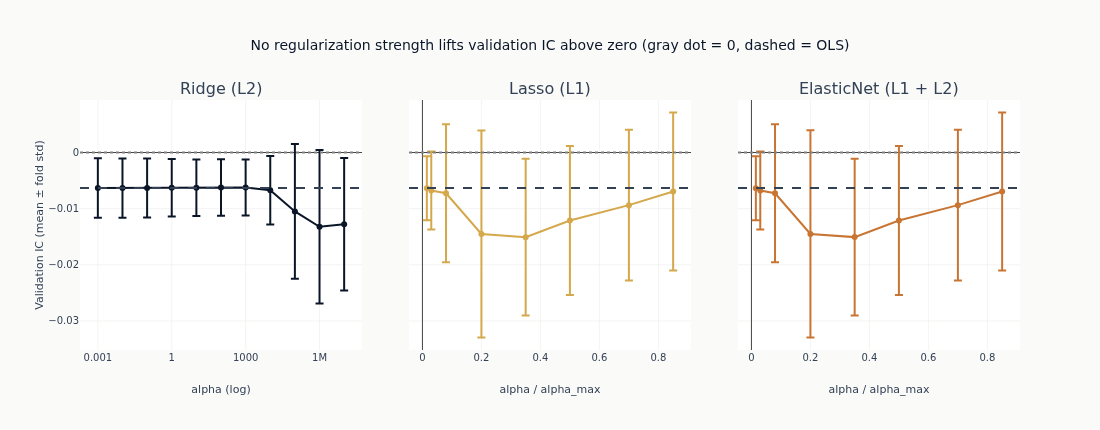

In [9]:
_FAMILY_LABEL = {"ridge": "Ridge", "lasso": "Lasso", "enet": "ElasticNet"}
_FAMILY_COLOR = {
    "Ridge": COLORS["blue"],
    "Lasso": COLORS["amber"],
    "ElasticNet": COLORS["copper"],
}


def _parse_config(name):
    """Return (family_label, penalty_strength) from a linear preset name."""
    if name == "ols":
        return "OLS", None
    prefix, _, suffix = name.partition("_")
    return _FAMILY_LABEL.get(prefix, prefix), float(suffix[1:])


path_rows = []
for r in active:
    fam, strength = _parse_config(r["config"]["config_name"])
    path_rows.append(
        {"family": fam, "strength": strength, "ic": r["ic_mean"], "ic_std": r["ic_std"]}
    )

ols_ic = next((p["ic"] for p in path_rows if p["family"] == "OLS"), None)

fig = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=["Ridge (L2)", "Lasso (L1)", "ElasticNet (L1 + L2)"],
    shared_yaxes=True,
    horizontal_spacing=0.05,
)
for col, (fam, log_x) in enumerate([("Ridge", True), ("Lasso", False), ("ElasticNet", False)], 1):
    rows = sorted((p for p in path_rows if p["family"] == fam), key=lambda p: p["strength"])
    fig.add_trace(
        go.Scatter(
            x=[p["strength"] for p in rows],
            y=[p["ic"] for p in rows],
            error_y=dict(type="data", array=[p["ic_std"] for p in rows], visible=True),
            mode="lines+markers",
            line=dict(color=_FAMILY_COLOR[fam]),
            marker=dict(size=6),
            showlegend=False,
        ),
        row=1,
        col=col,
    )
    fig.add_hline(y=0.0, line=dict(color="gray", dash="dot"), row=1, col=col)
    if ols_ic is not None:
        fig.add_hline(y=ols_ic, line=dict(color=COLORS["neutral"], dash="dash"), row=1, col=col)
    if log_x:
        fig.update_xaxes(type="log", row=1, col=col)

fig.update_layout(
    template="ml4t",
    height=430,
    width=1100,
    title_text="No regularization strength lifts validation IC above zero (gray dot = 0, "
    "dashed = OLS)",
)
fig.update_xaxes(title_text="alpha (log)", row=1, col=1)
fig.update_xaxes(title_text="alpha / alpha_max", row=1, col=2)
fig.update_xaxes(title_text="alpha / alpha_max", row=1, col=3)
fig.update_yaxes(title_text="Validation IC (mean ± fold std)", row=1, col=1)
fig.show()

### Coefficient shrinkage

The mechanism behind the flat IC path: L1 penalties (Lasso, ElasticNet) drive
coefficients to exactly zero as the penalty rises, so the model discards
features; the L2 penalty (Ridge) shrinks coefficients smoothly rather than
zeroing them. With no feature carrying standalone signal, sparsification neither
helps nor hurts - it simply trades one near-zero predictor for another.

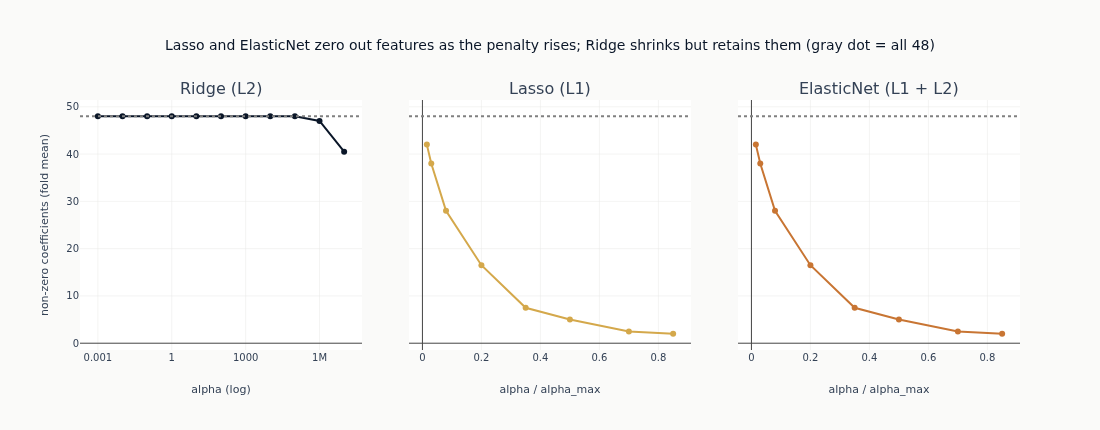

In [10]:
coef_rows = []
for cfg in configs:
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    coef_path = get_training_dir(CASE_STUDY_ID, spec) / "coefficients.parquet"
    if not coef_path.exists():
        continue
    cdf = pd.read_parquet(coef_path)
    cdf = cdf[cdf["feature"] != "_intercept_"]
    per_fold = cdf.groupby("fold")["coefficient"].apply(lambda s: (s.abs() > 1e-6).sum())
    fam, strength = _parse_config(cfg["config_name"])
    if strength is not None:
        coef_rows.append({"family": fam, "strength": strength, "nonzero": per_fold.mean()})

if coef_rows:
    n_features = len(feature_names)
    fig = make_subplots(
        rows=1,
        cols=3,
        subplot_titles=["Ridge (L2)", "Lasso (L1)", "ElasticNet (L1 + L2)"],
        shared_yaxes=True,
        horizontal_spacing=0.05,
    )
    for col, (fam, log_x) in enumerate(
        [("Ridge", True), ("Lasso", False), ("ElasticNet", False)], 1
    ):
        rows = sorted((c for c in coef_rows if c["family"] == fam), key=lambda c: c["strength"])
        if not rows:
            continue
        fig.add_trace(
            go.Scatter(
                x=[c["strength"] for c in rows],
                y=[c["nonzero"] for c in rows],
                mode="lines+markers",
                line=dict(color=_FAMILY_COLOR[fam]),
                marker=dict(size=6),
                showlegend=False,
            ),
            row=1,
            col=col,
        )
        fig.add_hline(y=n_features, line=dict(color="gray", dash="dot"), row=1, col=col)
        if log_x:
            fig.update_xaxes(type="log", row=1, col=col)

    fig.update_layout(
        template="ml4t",
        height=430,
        width=1100,
        title_text=f"Lasso and ElasticNet zero out features as the penalty rises; "
        f"Ridge shrinks but retains them (gray dot = all {n_features})",
    )
    fig.update_xaxes(title_text="alpha (log)", row=1, col=1)
    fig.update_xaxes(title_text="alpha / alpha_max", row=1, col=2)
    fig.update_xaxes(title_text="alpha / alpha_max", row=1, col=3)
    fig.update_yaxes(title_text="non-zero coefficients (fold mean)", row=1, col=1)
    fig.show()

## 5. Register Results

Each config is registered in the unified registry with its predictions,
IC metrics, and full provenance (training hash = SHA256 of config + label
+ features + folds). Identical configs produce the same hash - re-running
updates rather than duplicates.

In [11]:
for r in to_register:
    cfg = r["config"]
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(folds),
        train_sample_frac=TRAIN_SAMPLE_FRAC,
    )
    t_hash = register_training_run(
        CASE_STUDY_ID,
        spec=spec,
        entry_point="06_linear",
        started_at=r.get("started_at"),
        elapsed_s=r.get("elapsed_s"),
    )

    # Save coefficients to registry training dir
    train_dir = get_training_dir(CASE_STUDY_ID, spec)
    coefs = r.get("coefficients", [])
    if coefs:
        pd.DataFrame(coefs).to_parquet(train_dir / "coefficients.parquet", index=False)

    metrics = {"ic_mean": r["ic_mean"], "ic_std": r["ic_std"]}
    register_prediction_set(
        CASE_STUDY_ID,
        t_hash,
        split=PREDICTION_SPLIT,
        predictions=r["predictions"],
        task_type=mds.task_type,
        class_values=mds.class_values or None,
        eval_col="eval_actual" if mds.eval_label_col else None,
        metrics=metrics,
    )
    print(f"  registered {cfg['config_name']:25s}  IC={r['ic_mean']:+.4f}")

## 6. Key Takeaways

Validation IC stays negative and near zero across every regularization setting:
the best linear model (Ridge, alpha=100) reaches only IC=-0.006, and OLS, Ridge,
Lasso, and ElasticNet are statistically indistinguishable. Regularization changes
which coefficients survive but not the outcome, because no single feature carries
standalone signal (none survive FDR correction in `05_evaluation`). Linear
combination of weak, largely uncorrelated signals does not manufacture aggregate
signal here.

The open question for Ch12 is whether gradient boosting recovers structure that
linear models cannot represent: non-linear interactions among the option-implied
features and GARCH volatility state - for example, whether elevated conditional
volatility flips the sign of the momentum payoff.

**Next**: [`07_gbm`](07_gbm.ipynb) tests gradient boosting across leaf-count and
loss-function configurations to evaluate non-linear feature interactions.